Step 1: Generating Synthetic Data
Generated dataset with 200 samples (120 training, 80 test)
Simulated semi-supervised training data: 37 labeled, 83 unlabeled


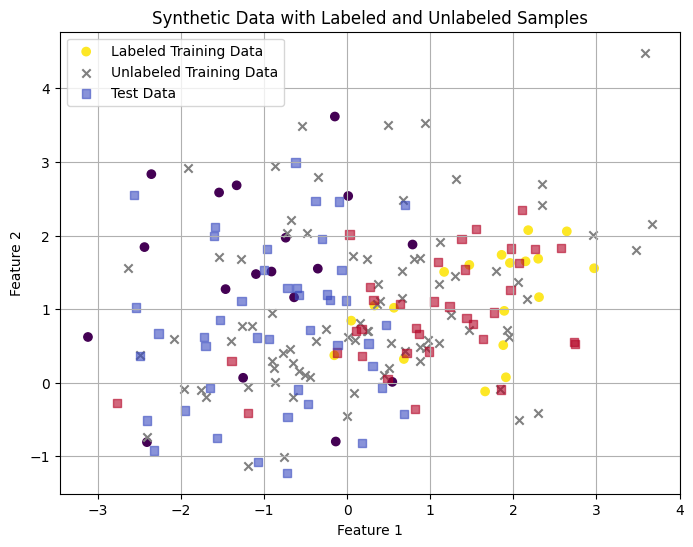


Step 2: Defining a Weak Supervision Heuristic
Applied weak supervision heuristic to 83 unlabeled samples.
Weakly labeled 34 samples as class 1.

Step 3: Combining Weak Labels with Initial Labeled Data
Combined initial labeled data with 34 weak labels.
Labels after incorporating weak supervision (-1 indicates still unlabeled):


,count
1,53
-1,49
0,18



Step 4: Applying Self-Training
Self-training completed.

Step 5: Evaluating the Model
Test Accuracy after Self-Training: 0.8375

Evaluating a model trained only on initial labeled data:
Test Accuracy with only initial labeled data: 0.8125

Step 6: Visualizing the Decision Boundary


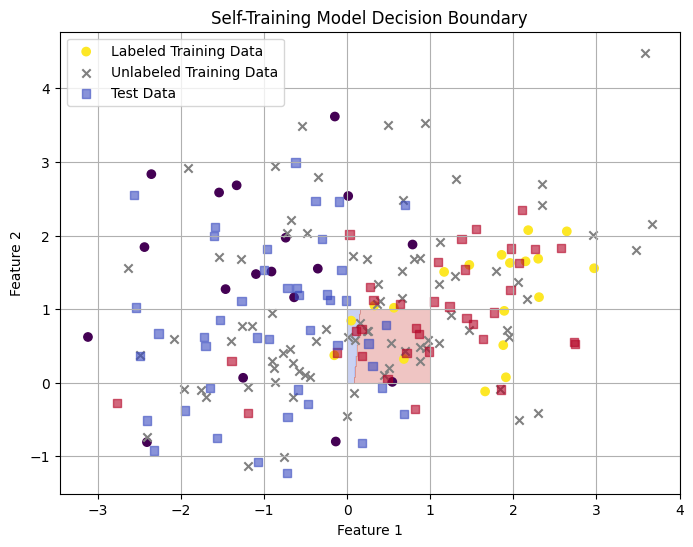

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Step 1: Generating Synthetic Data")
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42, n_clusters_per_class=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

unlabeled_percentage = 0.7
rng = np.random.RandomState(42)
unlabeled_indices = rng.rand(len(y_train)) < unlabeled_percentage
y_train_semi = np.copy(y_train)
y_train_semi[unlabeled_indices] = -1

print(f"Generated dataset with {len(X)} samples ({len(X_train)} training, {len(X_test)} test)")
print(f"Simulated semi-supervised training data: {np.sum(y_train_semi != -1)} labeled, {np.sum(y_train_semi == -1)} unlabeled")

plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train_semi != -1, 0], X_train[y_train_semi != -1, 1], c=y_train_semi[y_train_semi != -1], cmap='viridis', marker='o', label='Labeled Training Data')
plt.scatter(X_train[y_train_semi == -1, 0], X_train[y_train_semi == -1, 1], c='gray', marker='x', label='Unlabeled Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='s', alpha=0.6, label='Test Data')
plt.title('Synthetic Data with Labeled and Unlabeled Samples')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print("\nStep 2: Defining a Weak Supervision Heuristic")
def weak_label_heuristic(X):
    weak_labels = np.full(X.shape[0], -1)
    weakly_labeled_indices = X[:, 0] > 0.5
    weak_labels[weakly_labeled_indices] = 1
    return weak_labels

X_unlabeled_train = X_train[y_train_semi == -1]
weak_labels_unlabeled = weak_label_heuristic(X_unlabeled_train)

print(f"Applied weak supervision heuristic to {len(X_unlabeled_train)} unlabeled samples.")
print(f"Weakly labeled {np.sum(weak_labels_unlabeled != -1)} samples as class 1.")


print("\nStep 3: Combining Weak Labels with Initial Labeled Data")
y_train_combined = np.copy(y_train_semi)

original_unlabeled_indices = np.where(y_train_semi == -1)[0]

weakly_labeled_count = 0
for i, original_index in enumerate(original_unlabeled_indices):
    if weak_labels_unlabeled[i] != -1:
        if y_train_combined[original_index] == -1:
             y_train_combined[original_index] = weak_labels_unlabeled[i]
             weakly_labeled_count += 1

print(f"Combined initial labeled data with {weakly_labeled_count} weak labels.")
print("Labels after incorporating weak supervision (-1 indicates still unlabeled):")
display(pd.Series(y_train_combined).value_counts())


print("\nStep 4: Applying Self-Training")
base_classifier = LogisticRegression(max_iter=200)

self_training_model = SelfTrainingClassifier(base_classifier, threshold=0.8)

self_training_model.fit(X_train, y_train_combined)

print("Self-training completed.")

print("\nStep 5: Evaluating the Model")
accuracy = self_training_model.score(X_test, y_test)
print(f"Test Accuracy after Self-Training: {accuracy:.4f}")

print("\nEvaluating a model trained only on initial labeled data:")
X_train_initial_labeled = X_train[y_train_semi != -1]
y_train_initial_labeled = y_train_semi[y_train_semi != -1]

if len(X_train_initial_labeled) > 0:
    initial_model = LogisticRegression(max_iter=200)
    initial_model.fit(X_train_initial_labeled, y_train_initial_labeled)
    initial_accuracy = initial_model.score(X_test, y_test)
    print(f"Test Accuracy with only initial labeled data: {initial_accuracy:.4f}")
else:
    print("No initially labeled data to train a comparison model.")


print("\nStep 6: Visualizing the Decision Boundary")
plt.figure(figsize=(8, 6))
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
Z = self_training_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

contour = ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)

plt.scatter(X_train[y_train_semi != -1, 0], X_train[y_train_semi != -1, 1], c=y_train_semi[y_train_semi != -1], cmap='viridis', marker='o', label='Labeled Training Data')
plt.scatter(X_train[y_train_semi == -1, 0], X_train[y_train_semi == -1, 1], c='gray', marker='x', label='Unlabeled Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='s', alpha=0.6, label='Test Data')

plt.title('Self-Training Model Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


Step 7: Applying Weak Supervision with a Downloaded Dataset
Applied weak supervision using simulated downloaded data to 83 unlabeled samples.
Weakly labeled 37 samples based on the downloaded data heuristic.

Step 8: Combining New Weak Labels with Existing Labels
Combined existing labels with 18 new weak labels from the downloaded data.
Labels after incorporating both weak supervision heuristics (-1 indicates still unlabeled):


,count
1,71
-1,31
0,18



Step 9: Re-applying Self-Training with Updated Labels
Self-training completed with updated labels.

Step 10: Evaluating the New Model
Test Accuracy after Self-Training with Updated Labels: 0.6000

Step 11: Visualizing the New Decision Boundary


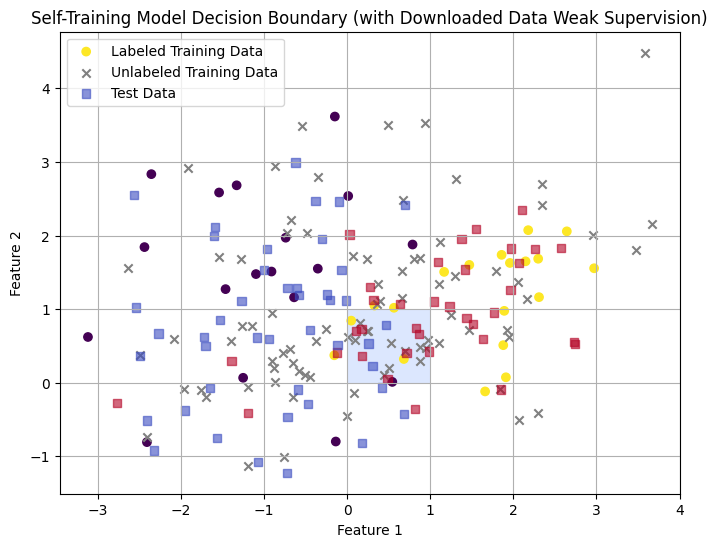

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42, n_clusters_per_class=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

unlabeled_percentage = 0.7
rng = np.random.RandomState(42)
unlabeled_indices = rng.rand(len(y_train)) < unlabeled_percentage
y_train_semi = np.copy(y_train)
y_train_semi[unlabeled_indices] = -1

def weak_label_heuristic(X):
    weak_labels = np.full(X.shape[0], -1)
    weakly_labeled_indices = X[:, 0] > 0.5
    weak_labels[weakly_labeled_indices] = 1
    return weak_labels

X_unlabeled_train_for_initial_heuristic = X_train[y_train_semi == -1]
weak_labels_unlabeled_initial = weak_label_heuristic(X_unlabeled_train_for_initial_heuristic)

y_train_combined = np.copy(y_train_semi)

original_unlabeled_indices_initial = np.where(y_train_semi == -1)[0]

for i, original_index in enumerate(original_unlabeled_indices_initial):
    if weak_labels_unlabeled_initial[i] != -1:
        if y_train_combined[original_index] == -1:
             y_train_combined[original_index] = weak_labels_unlabeled_initial[i]


print("\nStep 7: Applying Weak Supervision with a Downloaded Dataset")

unlabeled_indices_original = np.where(y_train_semi == -1)[0]
X_unlabeled_train_actual = X_train[unlabeled_indices_original]

external_scores_unlabeled = X_unlabeled_train_actual[:, 1] + np.random.randn(X_unlabeled_train_actual.shape[0]) * 0.5

def weak_label_from_downloaded_data(external_scores):
    weak_labels = np.full(external_scores.shape[0], -1)
    weakly_labeled_indices = external_scores > np.mean(external_scores)
    weak_labels[weakly_labeled_indices] = 1
    return weak_labels

weak_labels_from_downloaded = weak_label_from_downloaded_data(external_scores_unlabeled)

print(f"Applied weak supervision using simulated downloaded data to {len(X_unlabeled_train_actual)} unlabeled samples.")
print(f"Weakly labeled {np.sum(weak_labels_from_downloaded != -1)} samples based on the downloaded data heuristic.")

print("\nStep 8: Combining New Weak Labels with Existing Labels")

y_train_combined_new = np.copy(y_train_combined)

newly_weakly_labeled_count = 0
for i, original_index in enumerate(unlabeled_indices_original):
    if weak_labels_from_downloaded[i] != -1:
        if y_train_combined_new[original_index] == -1:
            y_train_combined_new[original_index] = weak_labels_from_downloaded[i]
            newly_weakly_labeled_count += 1

print(f"Combined existing labels with {newly_weakly_labeled_count} new weak labels from the downloaded data.")
print("Labels after incorporating both weak supervision heuristics (-1 indicates still unlabeled):")
display(pd.Series(y_train_combined_new).value_counts())

print("\nStep 9: Re-applying Self-Training with Updated Labels")

base_classifier_new = LogisticRegression(max_iter=200)

self_training_model_new = SelfTrainingClassifier(base_classifier_new, threshold=0.8)

self_training_model_new.fit(X_train, y_train_combined_new)

print("Self-training completed with updated labels.")

print("\nStep 10: Evaluating the New Model")

accuracy_new = self_training_model_new.score(X_test, y_test)
print(f"Test Accuracy after Self-Training with Updated Labels: {accuracy_new:.4f}")

print("\nStep 11: Visualizing the New Decision Boundary")
plt.figure(figsize=(8, 6))
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
Z_new = self_training_model_new.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

contour_new = ax.contourf(xx, yy, Z_new, cmap='coolwarm', alpha=0.3)

plt.scatter(X_train[y_train_semi != -1, 0], X_train[y_train_semi != -1, 1], c=y_train_semi[y_train_semi != -1], cmap='viridis', marker='o', label='Labeled Training Data')
plt.scatter(X_train[y_train_semi == -1, 0], X_train[y_train_semi == -1, 1], c='gray', marker='x', label='Unlabeled Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='s', alpha=0.6, label='Test Data')

plt.title('Self-Training Model Decision Boundary (with Downloaded Data Weak Supervision)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()